# Output Visualization and Analysis

This notebook focuses on the systematic visualization and diagnostic analysis of model or observational output data. The goal is to transform raw outputs into physically interpretable insights through structured processing, statistical evaluation, and clear graphical representation.


### Snow and Ice Category Classification

To classify snow and ice layers into physically meaningful categories based on two primary inputs:

- **`mk` (marker code)**: Encodes the material type or origin (e.g., fresh snow, meteoric ice, glacier ice)  
- **`lwc` (liquid water content, %)**: Indicates the degree of wetness or melt within the material  
- **`above_ref` (boolean)**: Specifies whether the layer lies above a defined reference horizon  

## Classification Logic

The classification follows a rule-based structure combining material type (`mk`) with thermodynamic state (`lwc`):

### 1. Fresh Snow (mk = 0, 1, 2)
Fresh snow is categorized based on its liquid water content:

- **Dry Snow** (`lwc < 5%`) → Category 1  
- **Wet Snow** (`5% ≤ lwc < 15%`) → Category 2  
- **Snow Slush** (`lwc ≥ 15%`) → Category 3  

This reflects the transition from dry, porous snow to increasingly saturated and slushy conditions.

---

### 2. Meteoric-Ice Markers (mk = 11, 12, 21, 22)
These markers represent snow-like or refrozen meteoric material. They are treated similarly to wet snow:

- **Wet Snow-like** (`lwc < 15%`) → Category 2  
- **Slushy Snow-like** (`lwc ≥ 15%`) → Category 3  

---

### 3. Thermodynamic Ice (mk = 7, 8, 17, 18, 27, 28)

These markers correspond to more consolidated ice structures. Their classification depends on their position relative to a reference layer:

#### a) Above Reference (`above_ref = True`)
- **Meteoric Ice** (`lwc < 15%`) → Category 4  
- **Meteoric Ice Slush** (`lwc ≥ 15%`) → Category 5  

#### b) Below Reference (`above_ref = False`)
- Assigned to a distinct category:  
  - **Basal / Deep Ice** → Category 7  

This distinction allows separation between surface-derived meteoric ice and deeper, structurally different ice layers.

---

### 4. Reference Markers (mk = 9007, 9017, 9027)

These markers explicitly define the reference horizon within the profile:

- **Reference Layer** → Category 6  

---

### 5. Fallback Case

Any marker codes not explicitly handled are assigned:

- **Unknown / Other** → Category 0  

---

## Summary of Categories

| Category | Description                    |
|----------|------------------------------|
| 0        | Unknown / Other              |
| 1        | Dry Snow                     |
| 2        | Wet Snow                     |
| 3        | Snow Slush                   |
| 4        | Meteoric Ice                 |
| 5        | Meteoric Ice Slush           |
| 6        | Reference Layer              |
| 7        | Basal / Deep Ice             |

---

## Notes

- The **15% LWC threshold** is used to distinguish between solid and slushy states.  
- The **reference layer** provides a structural boundary for interpreting ice origin.  
- This classification enables consistent physical interpretation of stratified snow/ice profiles and supports further thermodynamic or mass-balance analysis.

## Plot of time-series for snow and ice category above the reference marker

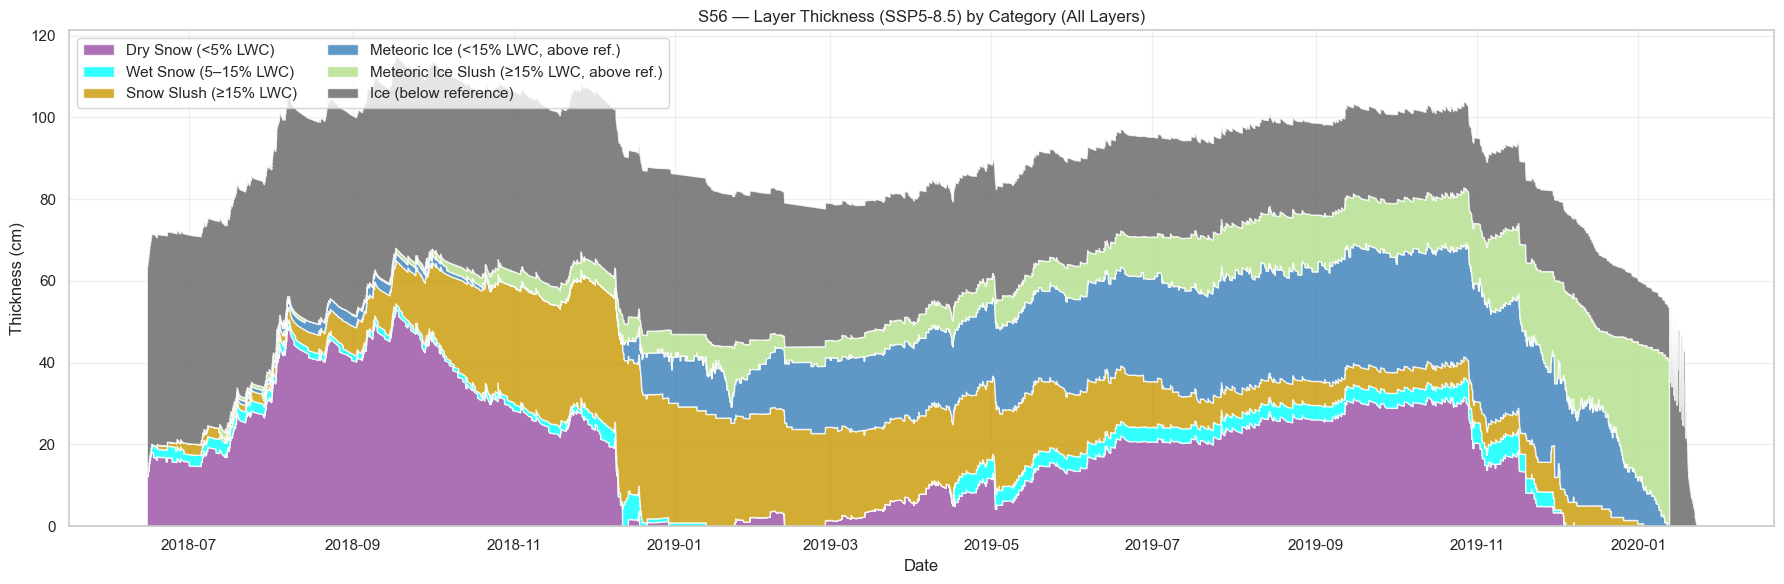

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from snowpat import snowpackreader as spr
import snowpat.pysmet as smet

sns.set_theme(style="whitegrid")

# --- 1) Read & classify PRO profiles ---
pro = spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro")
pro.discard_below_ground(discard=False)

dates    = pro.get_all_dates()
profiles = pro.get_all_profiles()

def group_mk(mk, lwc, above_ref=True):
    """
    above_ref = True  -> meteoric ice categories (4/5)
    above_ref = False -> plain ice category (7)
    """
    # Snow types
    if mk in {0, 1, 2}:
        return 1 if lwc < 5 else 2 if lwc < 15 else 3
    if mk in {11, 12, 21, 22}:
        return 2 if lwc < 15 else 3

    # Ice / meteoric ice
    if mk in {7, 8, 17, 18, 27, 28}:
        if above_ref:
            # Meteoric ice as before
            return 4 if lwc < 15 else 5
        else:
            # New category: "just ice" below reference
            return 7

    # Reference
    if mk in {9007, 9017, 9027}:
        return 6

    # Other
    return 0

group_labels = {
    1: "Dry Snow (<5% LWC)",
    2: "Wet Snow (5–15% LWC)",
    3: "Snow Slush (≥15% LWC)",
    4: "Meteoric Ice (<15% LWC, above ref.)",
    5: "Meteoric Ice Slush (≥15% LWC, above ref.)",
    6: "Reference",
    7: "Ice (below reference)",
    0: "Other"
}

group_colors = {
    1: "#984ea3",
    2: "#00ffff",
    3: "#c99700",
    4: "#377eb8",
    5: "#b2df8a",
    6: "#000000",
    7: "#636363",  # new color for 'Ice (below reference)'
    0: "#999999"
}

# include new ice-below-ref category in the stack
cat_ids = [1, 2, 3, 4, 5, 7]
series = {cid: [] for cid in cat_ids}

for prof in profiles:
    dfp   = prof.toDf(CodesToName=pro.DataCodes)
    mk    = dfp["element mk"].values
    lwc   = dfp["liquid water content by volume"].values
    thick = dfp["layer thickness"].values

    # Find reference layer index (if any)
    idx_ref = np.where(np.isin(mk, [9007, 9017, 9027]))[0]
    if idx_ref.size:
        i_ref = idx_ref[0]
    else:
        # If no reference is found, treat everything as "above"
        i_ref = -1

    # Classify each layer with knowledge of above/below reference
    grp = []
    for k, (m, l) in enumerate(zip(mk, lwc)):
        above_ref = (k > i_ref)  # layers with index > i_ref are above reference
        grp.append(group_mk(m, l, above_ref=above_ref))
    grp = np.array(grp)

    # Sum thickness per category
    for cid in cat_ids:
        series[cid].append(np.sum(thick[grp == cid]))

# convert lists to arrays
for cid in cat_ids:
    series[cid] = np.array(series[cid])


# precipitation_change function
def precipitation_change(temp_inc, base_precip, sens=0.0667):
    return base_precip * (1 + sens)**temp_inc

# parameters
warming     = 0  # °C
sensitivity = 0

# --- 3) Plot ---
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.stackplot(
    dates,
    *[series[c] for c in cat_ids],
    labels=[group_labels[c] for c in cat_ids],
    colors=[group_colors[c] for c in cat_ids],
    alpha=0.8
)
ax1.set_ylabel("Thickness (cm)")
ax1.set_xlabel("Date")
ax1.set_title(f"{pro.metadata['StationName']} — Layer Thickness (SSP5-8.5) by Category (All Layers)")
ax1.legend(loc='upper left', ncol=2)
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison box-plot for thickness distribution (mean,median) for every scenarios. 

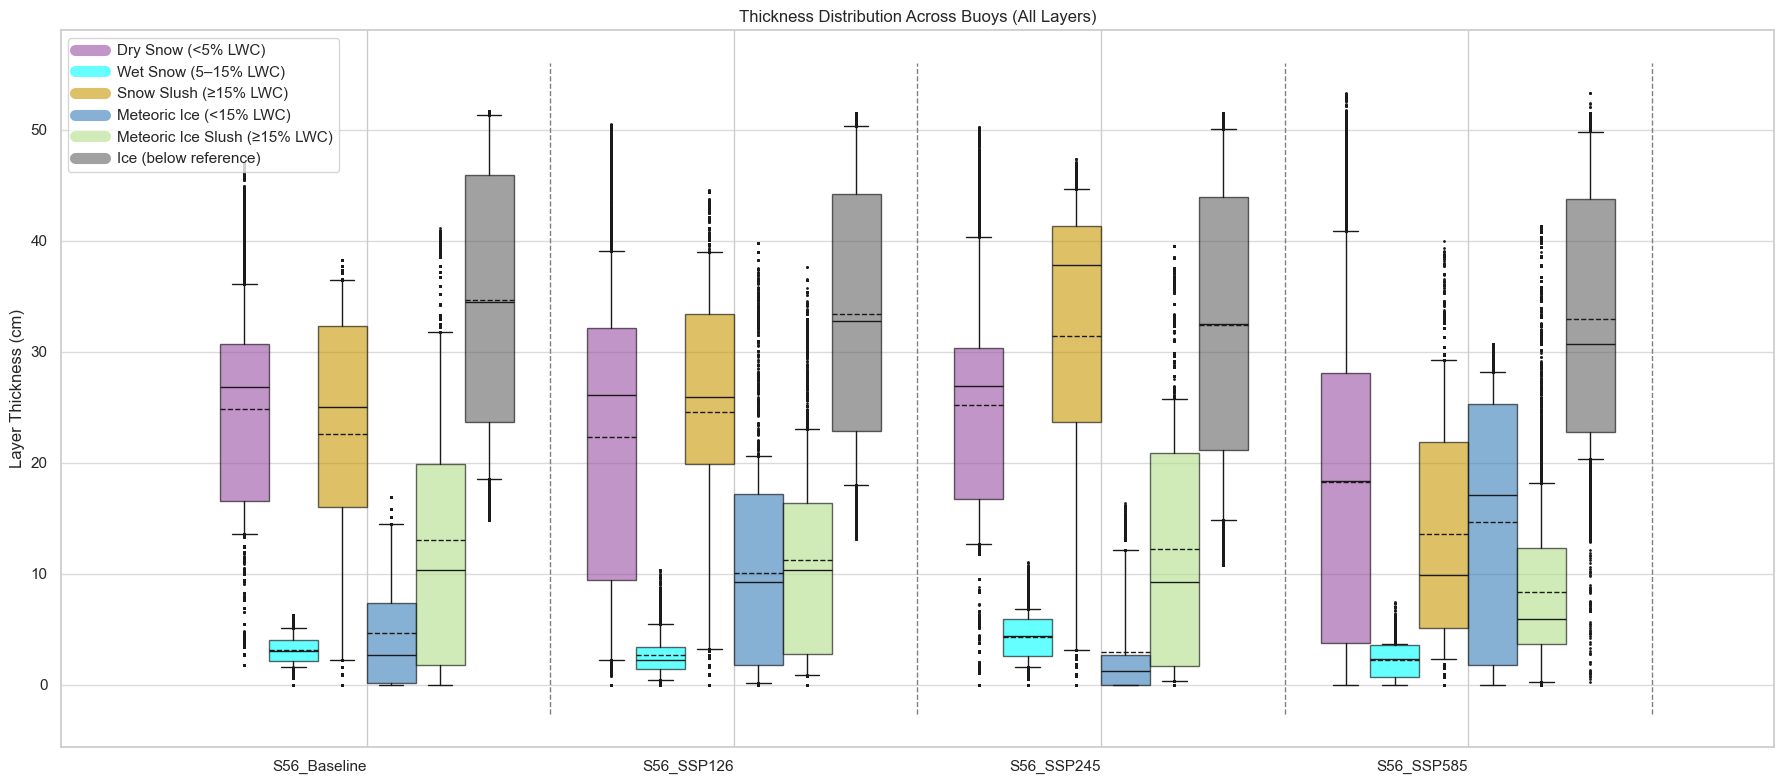

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from snowpat import snowpackreader as spr

# 1) Seaborn theme
sns.set_theme(style="whitegrid")

# 2) Load stations
stations = {
    "S56_Baseline":  spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro"),
    "S56_SSP126":  spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro"),
    "S56_SSP245":  spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro"),
    "S56_SSP585": spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro"),
}

for pr in stations.values():
    pr.discard_below_ground(discard=False)

def group_mk(mk, lwc, above_ref=True):
    """
    above_ref = True  -> meteoric ice categories (4/5) for ice mk-codes
    above_ref = False -> plain ice category (7) for ice mk-codes
    """
    # 0–2: fresh snow
    if mk in {0, 1, 2}:
        if   lwc <  5: return 1   # Dry Snow (<5% LWC)
        elif lwc < 15: return 2   # Wet Snow (5–15% LWC)
        else:           return 3   # Snow Slush (≥15% LWC)

    # 11,12,21,22: meteoric‐ice markers (treated as snow-like)
    if mk in {11, 12, 21, 22}:
        if   lwc < 15: return 2   # Wet Snow (<15% LWC)
        else:           return 3   # Snow Slush (≥15% LWC)

    # 7,8,17,18,27,28: glacier/thermodynamic ice
    if mk in {7, 8, 17, 18, 27, 28}:
        if above_ref:
            # Meteoric ice above reference
            if lwc < 15:
                return 4          # Meteoric Ice (<15% LWC)
            else:
                return 5          # Meteoric Ice Slush (≥15% LWC)
        else:
            # New category: ice below reference
            return 7

    # reference markers
    if mk in {9007, 9017, 9027}:
        return 6

    return 0  # other / unknown

# include new category 7 for ice below reference
cats = [1, 2, 3, 4, 5, 7]

cat_labels = {
    1: "Dry Snow (<5% LWC)",
    2: "Wet Snow (5–15% LWC)",
    3: "Snow Slush (≥15% LWC)",
    4: "Meteoric Ice (<15% LWC)",
    5: "Meteoric Ice Slush (≥15% LWC)",
    7: "Ice (below reference)",
}

cat_colors = {
    1: "#984ea3",
    2: "#00ffff",
    3: "#c99700",
    4: "#377eb8",
    5: "#b2df8a",
    7: "#636363",   # dark grey for ice below ref
}

# 4) Build time-series of summed thickness for each station & category (ALL layers)
thk_ts = {st:{c:[] for c in cats} for st in stations}
for st, pr in stations.items():
    for prof in pr.get_all_profiles():
        df    = prof.toDf(CodesToName=pr.DataCodes)
        mk    = df["element mk"].values
        lwc   = df["liquid water content by volume"].values
        thick = df["layer thickness"].values  # cm (as in your original script)

        # Find reference layer index (if any)
        idx_ref = np.where(np.isin(mk, [9007, 9017, 9027]))[0]
        if idx_ref.size:
            i_ref = idx_ref[0]
        else:
            # If no reference, treat everything as "above" (no cat 7)
            i_ref = -1

        mk_a    = mk
        lwc_a   = lwc
        thick_a = thick

        # classify with above/below reference info
        grp = []
        for k, (m, l) in enumerate(zip(mk_a, lwc_a)):
            above_ref = (k > i_ref)
            grp.append(group_mk(m, l, above_ref=above_ref))
        grp = np.array(grp)

        for c in cats:
            thk_ts[st][c].append(thick_a[grp==c].sum())

# 5) Plot grouped by station on X, categories within
stations_order = list(stations.keys())
n_st  = len(stations_order)
n_cat = len(cats)
width = 0.8 / n_cat

fig, ax = plt.subplots(figsize=(18,8))

for j, st in enumerate(stations_order):
    for i, c in enumerate(cats):
        data = thk_ts[st][c]
        x = j - 0.4 + width/2 + i*width
        bp = ax.boxplot(
            data,
            positions=[x],
            widths=width,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            whis=(10,90),
            medianprops=dict(color='k'),
            whiskerprops=dict(color='k', linewidth=1),
            capprops=dict(color='k'),
            flierprops=dict(
                marker='o',
                markerfacecolor='none',
                markeredgecolor='k',
                markersize=1
            )
        )
        patch = bp['boxes'][0]
        patch.set_facecolor(cat_colors[c])
        patch.set_alpha(0.6)
        bp['means'][0].set_color('k')

ax.set_xticks(range(n_st))
ax.set_xticklabels(stations_order, rotation=0, ha='right')
ax.set_ylabel("Layer Thickness (cm)")
ax.set_title("Thickness Distribution Across Buoys (All Layers)")
ax.grid(axis='y', alpha=0.7)

seps = np.arange(0.5, n_st, 1.0)
ax.vlines(x=seps, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
          colors='gray', linestyles='--', linewidth=1)

handles = [plt.Line2D([0],[0], color=cat_colors[c], lw=8, alpha=0.6) for c in cats]
ax.legend(
    handles,
    [cat_labels[c] for c in cats],
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

## Comparison Box-Plot for Mass Distribution (Mean and Median) Across Scenarios

The cumulative mass for each category is computed at every timestep as:

$$
\text{mass} = \text{layer thickness} \times \text{density}
$$

This formulation allows the analysis of how mass evolves over time for each scenario, enabling direct comparison of statistical measures such as the mean and median across different cases.

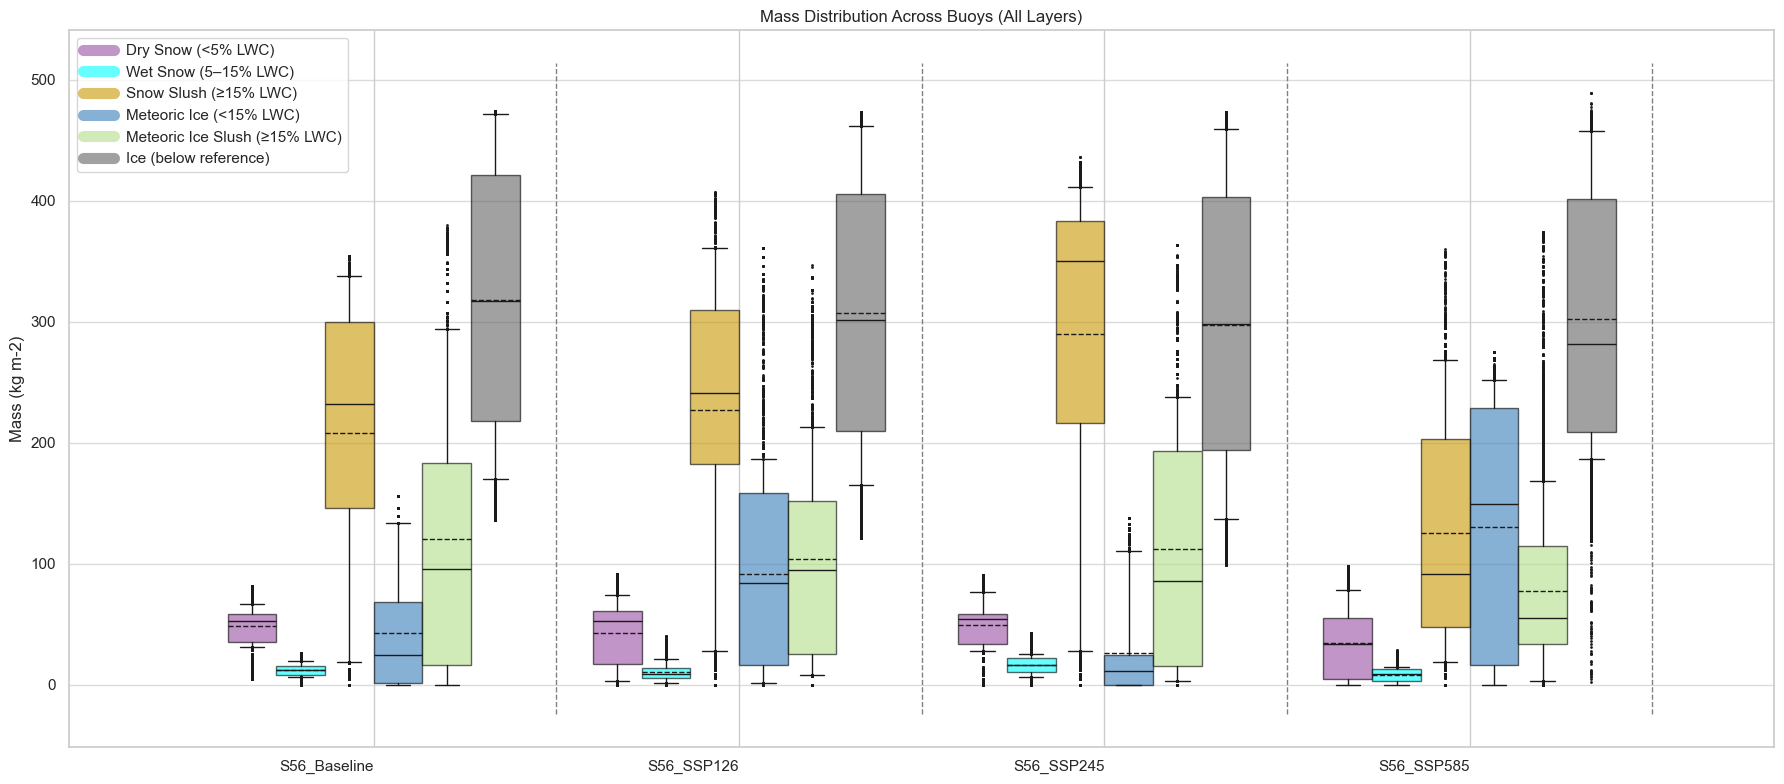

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from snowpat import snowpackreader as spr

# 1) Seaborn theme
sns.set_theme(style="whitegrid")

# 2) Load stations
stations = {
    "S56_Baseline":  spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro"),
    "S56_SSP126":  spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro"),
    "S56_SSP245":  spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro"),
    "S56_SSP585": spr.readPRO("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro"),
}

for pr in stations.values():
    pr.discard_below_ground(discard=False)

def group_mk(mk, lwc, above_ref=True):
    """
    above_ref = True  -> meteoric ice categories (4/5) for ice mk-codes
    above_ref = False -> plain ice category (7) for ice mk-codes
    """
    # 0–2: fresh snow
    if mk in {0, 1, 2}:
        if   lwc <  5: return 1   # Dry Snow (<5% LWC)
        elif lwc < 15: return 2   # Wet Snow (5–15% LWC)
        else:           return 3   # Snow Slush (≥15% LWC)

    # 11,12,21,22: meteoric-ice markers (still treated as snow-like)
    if mk in {11, 12, 21, 22}:
        if   lwc < 15: return 2   # Wet Snow (<15% LWC)
        else:           return 3   # Snow Slush (≥15% LWC)

    # 7,8,17,18,27,28: glacier/thermodynamic ice
    if mk in {7, 8, 17, 18, 27, 28}:
        if above_ref:
            # Meteoric ice above reference
            if lwc < 15:
                return 4          # Meteoric Ice (<15% LWC)
            else:
                return 5          # Meteoric Ice Slush (≥15% LWC)
        else:
            # New category: ice below reference
            return 7

    # reference markers
    if mk in {9007, 9017, 9027}:
        return 6

    return 0  # other / unknown

# categories including new ice-below-ref (7)
cats = [1, 2, 3, 4, 5, 7]

cat_labels  = {
    1: "Dry Snow (<5% LWC)",
    2: "Wet Snow (5–15% LWC)",
    3: "Snow Slush (≥15% LWC)",
    4: "Meteoric Ice (<15% LWC)",
    5: "Meteoric Ice Slush (≥15% LWC)",
    7: "Ice (below reference)",
}

cat_colors = {
    1: "#984ea3",
    2: "#00ffff",
    3: "#c99700",
    4: "#377eb8",
    5: "#b2df8a",
    7: "#636363",   # dark grey for ice below ref
}

# 4) Build time-series of summed mass for each station & category (ALL layers)
thk_ts = {st:{c:[] for c in cats} for st in stations}

for st, pr in stations.items():
    for prof in pr.get_all_profiles():
        df      = prof.toDf(CodesToName=pr.DataCodes)
        mk      = df["element mk"].values 
        lwc     = df["liquid water content by volume"].values  # %
        thick   = df["layer thickness"].values / 100.0         # m
        density = df["element density"].values                 # kg m⁻³
        mass_a  = thick * density                              # kg m⁻²

        # Find reference layer index (if any)
        idx_ref = np.where(np.isin(mk, [9007, 9017, 9027]))[0]
        if idx_ref.size:
            i_ref = idx_ref[0]
        else:
            # if no reference, treat everything as "above"
            i_ref = -1

        # Classify each layer with above/below reference
        grp = []
        for k, (m, l) in enumerate(zip(mk, lwc)):
            above_ref = (k > i_ref)
            grp.append(group_mk(m, l, above_ref=above_ref))
        grp = np.array(grp)

        for c in cats:
            thk_ts[st][c].append(mass_a[grp==c].sum())

# 5) Plot grouped by station on X, categories within
stations_order = list(stations.keys())
n_st  = len(stations_order)
n_cat = len(cats)
width = 0.8 / n_cat

fig, ax = plt.subplots(figsize=(18,8))

for j, st in enumerate(stations_order):
    for i, c in enumerate(cats):
        data = thk_ts[st][c]
        x = j - 0.4 + width/2 + i*width
        bp = ax.boxplot(
            data,
            positions=[x],
            widths=width,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            whis=(10,90),
            medianprops=dict(color='k'),
            whiskerprops=dict(color='k', linewidth=1),
            capprops=dict(color='k'),
            flierprops=dict(
                marker='o',
                markerfacecolor='none',
                markeredgecolor='k',
                markersize=1
            )
        )
        patch = bp['boxes'][0]
        patch.set_facecolor(cat_colors[c])
        patch.set_alpha(0.6)
        bp['means'][0].set_color('k')

ax.set_xticks(range(n_st))
ax.set_xticklabels(stations_order, rotation=0, ha='right')
ax.set_ylabel("Mass (kg m-2)")
ax.set_title("Mass Distribution Across Buoys (All Layers)")
ax.grid(axis='y', alpha=0.7)

seps = np.arange(0.5, n_st, 1.0)
ax.vlines(x=seps, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
          colors='gray', linestyles='--', linewidth=1)

handles = [plt.Line2D([0],[0], color=cat_colors[c], lw=8, alpha=0.6) for c in cats]
ax.legend(
    handles,
    [cat_labels[c] for c in cats],
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()